In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [110]:
df=pd.read_csv(r'C:\Users\nice\Desktop\projects\diabetes_prediction_project\data\diabetes_prediction_dataset.csv')

In [111]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [112]:
df["diabetes"].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

| Column Name           | Description                                                                 |
|-----------------------|-----------------------------------------------------------------------------|
| `gender`              | نوع الجنس: `Male`, `Female`             |
| `age`                 | عمر المريض (بالسنوات)                                                       |
| `hypertension`        | هل المريض يعاني من ضغط دم مرتفع؟ 0 = لا، 1 = نعم                           |
| `heart_disease`       | هل لدى المريض مرض في القلب؟ 0 = لا، 1 = نعم                                |
| `smoking_history`     | تاريخ التدخين: `never`, `former`, `current`, `ever`, `not current`, `No Info`|
| `bmi`                 | مؤشر كتلة الجسم (Body Mass Index) – يقيس الوزن نسبةً للطول                |
| `HbA1c_level`         | متوسط نسبة السكر في الدم خلال آخر 3 شهور (Hemoglobin A1c %)                |
| `blood_glucose_level` | مستوى الجلوكوز في الدم                           |
| `diabetes`            | هل المريض مصاب بالسكري؟ `Positive` أو `Negative`                           |



In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB


In [114]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [115]:
print(df.duplicated().sum())
print("-"*20)
df.isna().sum()

3854
--------------------


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [116]:
df.drop_duplicates(inplace=True)

In [117]:
df.loc[df["age"]<1,[ "age"]].sort_values(by="age",ascending=False)

,age
45362,0.88
23679,0.88
8295,0.88
94507,0.88
13368,0.88
...,...
46033,0.08
9683,0.08
29551,0.08
63616,0.08


<Axes: ylabel='age'>

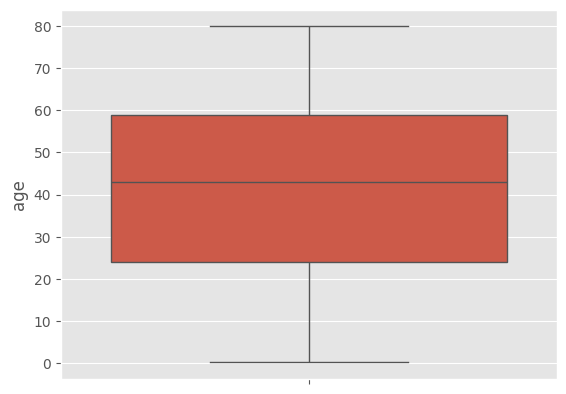

In [118]:
sns.boxplot(df["age"])

In [119]:
df["gender"].unique()

<ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [120]:
df.loc[df["gender"]=="Other",["gender"]]

,gender
12669,Other
14838,Other
16702,Other
18691,Other
23266,Other
31985,Other
33805,Other
34929,Other
35006,Other
40337,Other


In [121]:
df.loc[df["gender"]=="Other",["gender"]]=np.nan

In [122]:
df.dropna(inplace=True)

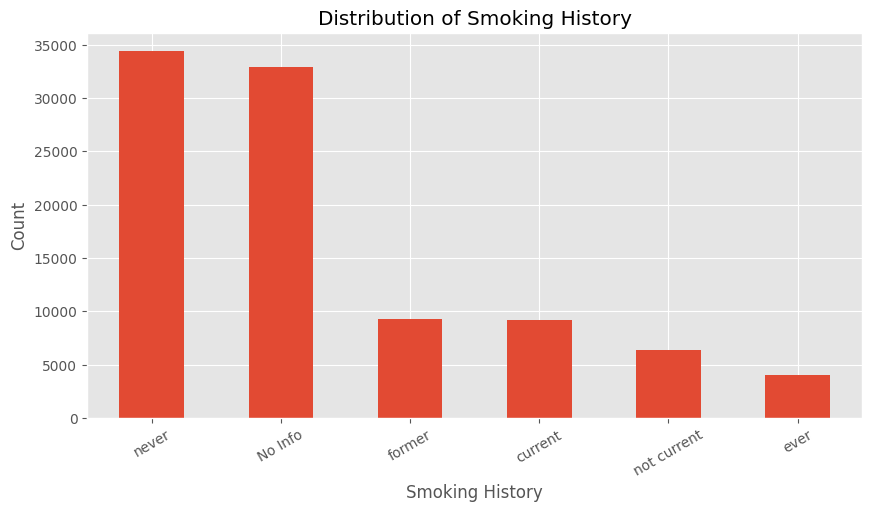

In [123]:
plt.figure(figsize=(10,5))
df["smoking_history"].value_counts().plot(kind='bar')
plt.xticks(rotation=30)
plt.xlabel("Smoking History")
plt.ylabel("Count")
plt.title("Distribution of Smoking History")
plt.show()

Text(0.5, 1.0, 'Distribution of gender')

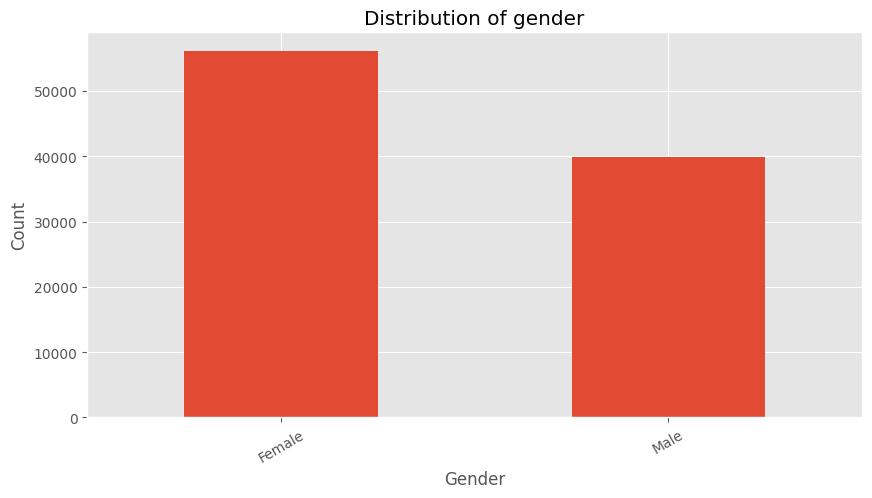

In [124]:
plt.figure(figsize=(10,5))
df["gender"].value_counts().plot(kind='bar')
plt.xticks(rotation=30)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Distribution of gender")

<Axes: >

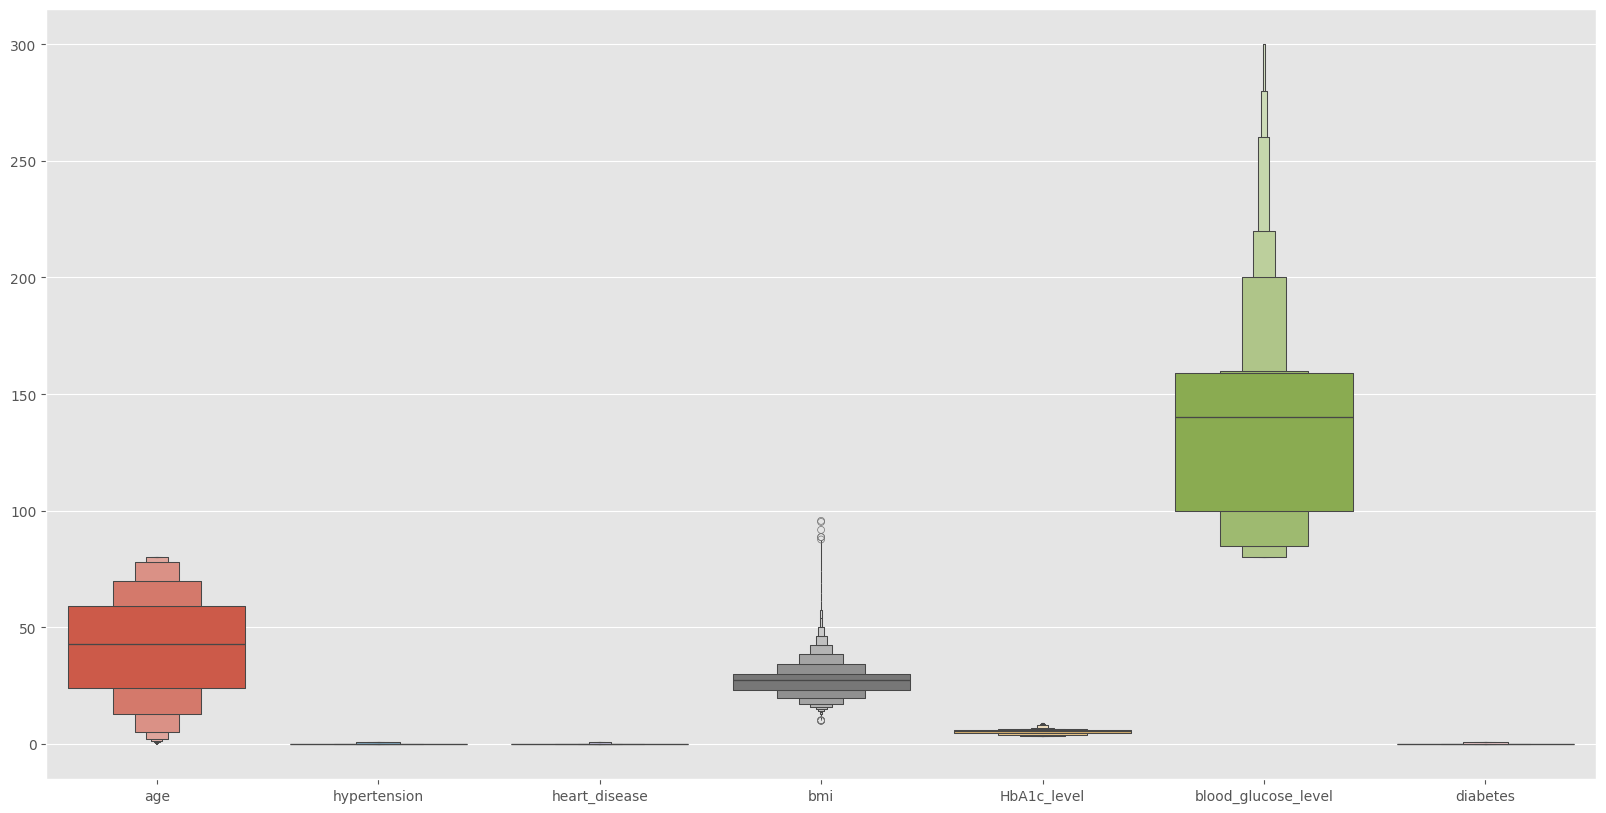

In [125]:
plt.figure(figsize=(20,10))
sns.boxenplot(df)

<Axes: xlabel='diabetes', ylabel='HbA1c_level'>

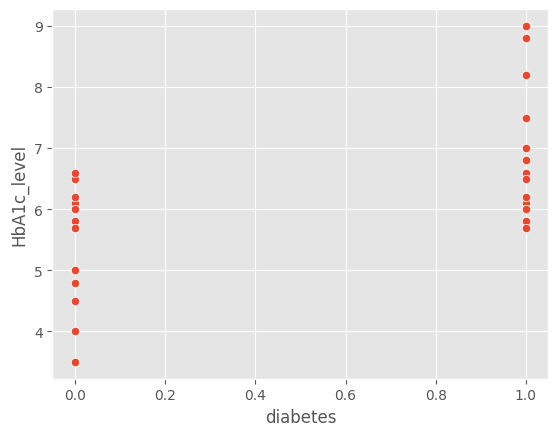

In [126]:
sns.scatterplot(x=df["diabetes"], y=df["HbA1c_level"])

<Axes: xlabel='diabetes', ylabel='blood_glucose_level'>

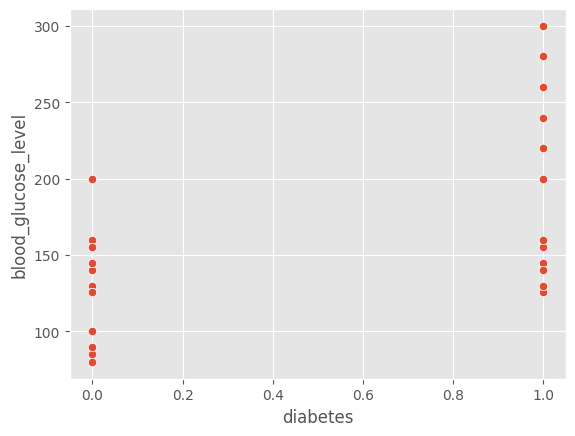

In [127]:
sns.scatterplot(x=df["diabetes"], y=df["blood_glucose_level"])

Text(0.5, 1.0, 'Diabetes by Gender')

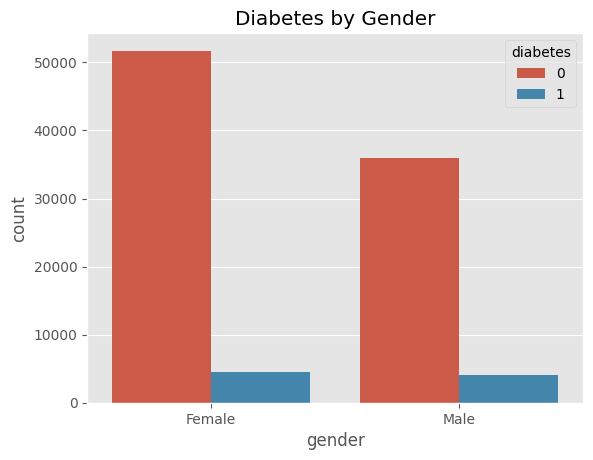

In [128]:
sns.countplot(x="gender", hue="diabetes", data=df)
plt.title("Diabetes by Gender")

<Axes: xlabel='hypertension', ylabel='count'>

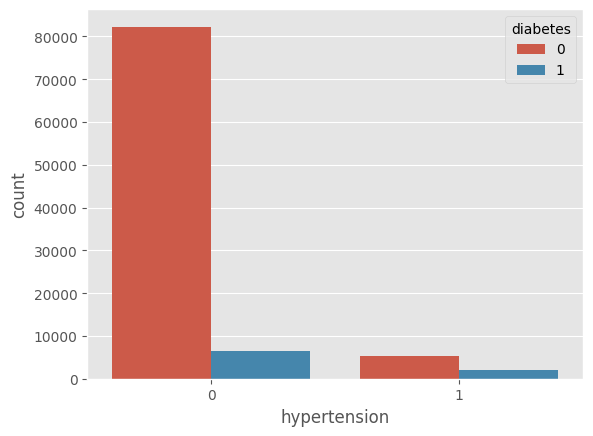

In [129]:
sns.countplot(x="hypertension", hue="diabetes", data=df)

<Axes: xlabel='heart_disease', ylabel='count'>

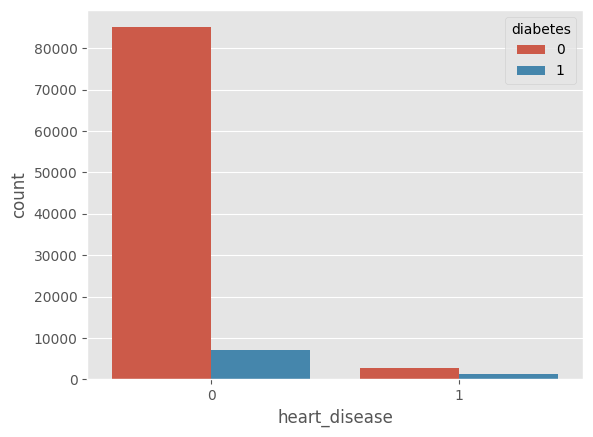

In [130]:
sns.countplot(x="heart_disease", hue="diabetes", data=df)

In [131]:
df.loc[df["diabetes"]==1,]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
6,Female,44.0,0,0,never,19.31,6.5,200,1
26,Male,67.0,0,1,not current,27.32,6.5,200,1
38,Male,50.0,1,0,current,27.32,5.7,260,1
40,Male,73.0,0,0,former,25.91,9.0,160,1
53,Female,53.0,0,0,former,27.32,7.0,159,1
...,...,...,...,...,...,...,...,...,...
99935,Female,65.0,1,1,never,33.55,8.2,140,1
99938,Male,55.0,0,1,former,30.42,6.2,300,1
99957,Female,61.0,0,0,No Info,34.45,6.5,280,1
99962,Female,58.0,1,0,never,38.31,7.0,200,1


In [132]:
df["diabetes"].value_counts()

diabetes
0    87646
1     8482
Name: count, dtype: int64

Text(0.5, 1.0, 'Diabetes Class Distribution')

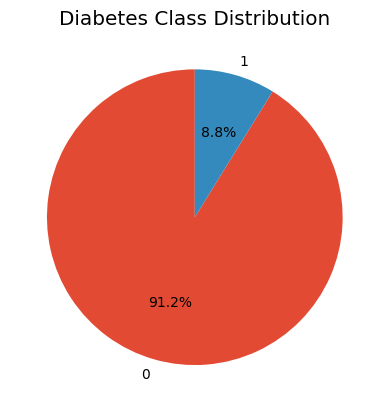

In [133]:
df["diabetes"].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title("Diabetes Class Distribution")

<Axes: xlabel='age', ylabel='Count'>

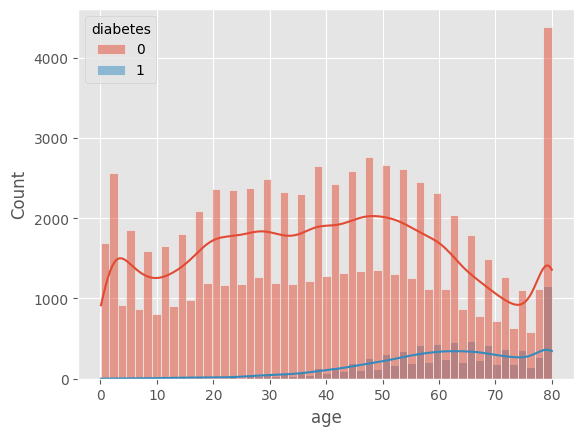

In [134]:
sns.histplot(data=df, x="age", hue="diabetes", kde=True)

In [135]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df["gender"]=le.fit_transform(df["gender"])
df["smoking_history"] = le.fit_transform(df["smoking_history"])

<Axes: >

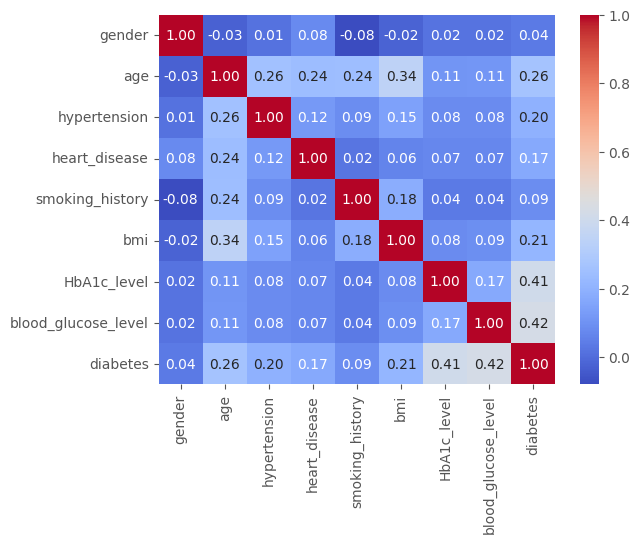

In [136]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

In [137]:
df["diabetes"].value_counts()

diabetes
0    87646
1     8482
Name: count, dtype: int64

In [138]:
from sklearn.model_selection import train_test_split
x=df.drop("diabetes",axis=1)
y=df["diabetes"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [139]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy=0.3, random_state=42)
x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

In [140]:
from sklearn.tree import DecisionTreeClassifier
model2= DecisionTreeClassifier(class_weight="balanced")
model2.fit(x_resampled, y_resampled)
y_pred2 = model2.predict(x_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred2))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred2))
print("roc_auc_score:",roc_auc_score(y_test, y_pred2))

Decision Tree Accuracy: 0.9479350879017997
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     17525
           1       0.70      0.72      0.71      1701

    accuracy                           0.95     19226
   macro avg       0.84      0.84      0.84     19226
weighted avg       0.95      0.95      0.95     19226

roc_auc_score: 0.8443074603258467


In [141]:
from sklearn.ensemble import RandomForestClassifier
model3=RandomForestClassifier(class_weight="balanced")
model3.fit(x_resampled, y_resampled)
y_pred3=model3.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred3))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred3))
print("roc_auc_score:",roc_auc_score(y_test, y_pred3))

Random Forest Accuracy: 0.9633309060647041
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     17525
           1       0.87      0.68      0.77      1701

    accuracy                           0.96     19226
   macro avg       0.92      0.84      0.87     19226
weighted avg       0.96      0.96      0.96     19226

roc_auc_score: 0.8373585228459218


In [142]:
from xgboost import XGBClassifier
model4 = XGBClassifier(
    scale_pos_weight=2,
    eval_metric='logloss',
    random_state=42
)
model4.fit(x_train,y_train)
y_pred4=model4.predict(x_test)
print("xgboost Accuracy:", accuracy_score(y_test, y_pred4))
print("xgboost Classification Report:\n", classification_report(y_test, y_pred4))
print("roc_auc_score:",roc_auc_score(y_test, y_pred4))

xgboost Accuracy: 0.9640070737542911
xgboost Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     17525
           1       0.87      0.70      0.77      1701

    accuracy                           0.96     19226
   macro avg       0.92      0.84      0.88     19226
weighted avg       0.96      0.96      0.96     19226

roc_auc_score: 0.8448956013958391


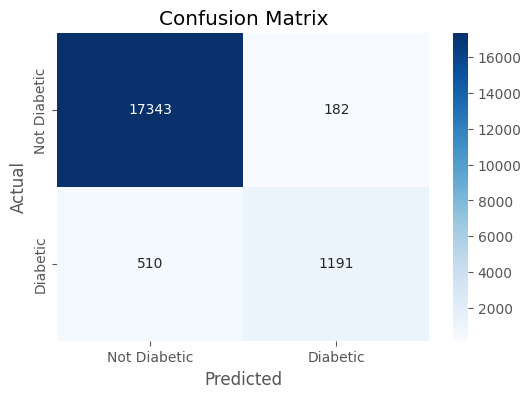

In [143]:
cm = confusion_matrix(y_test, y_pred4)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Diabetic', 'Diabetic'], yticklabels=['Not Diabetic', 'Diabetic'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

C:\Users\nice\AppData\Local\Temp\ipykernel_8772\1458056514.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette='Set2')


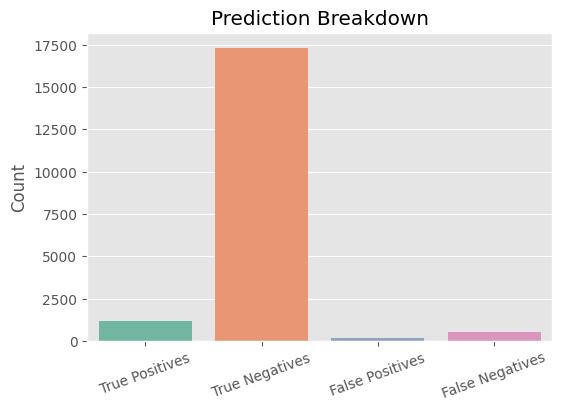

In [144]:
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
labels = ['True Positives', 'True Negatives', 'False Positives', 'False Negatives']
values = [TP, TN, FP, FN]
plt.figure(figsize=(6,4))
sns.barplot(x=labels, y=values, palette='Set2')
plt.title("Prediction Breakdown")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

C:\Users\nice\AppData\Local\Temp\ipykernel_8772\2711762097.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fi.values, y=fi.index, palette='viridis')


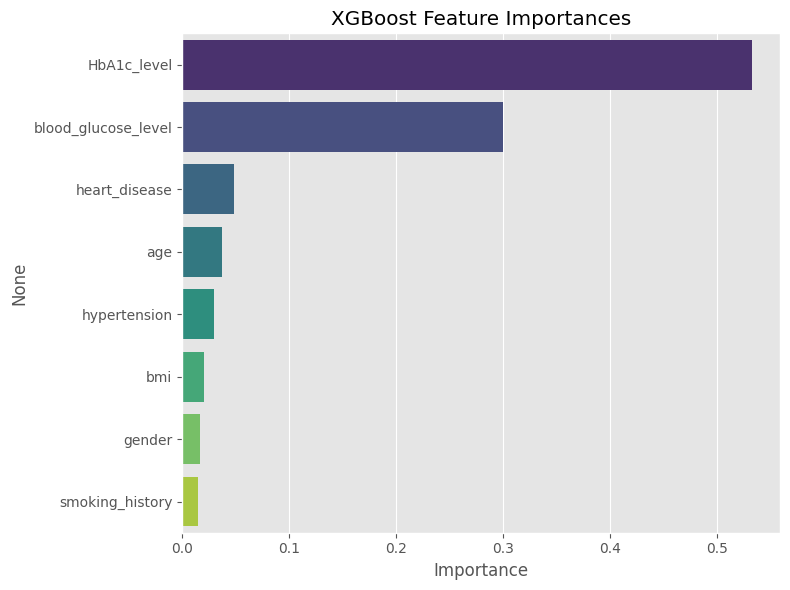

HbA1c_level            0.532160
blood_glucose_level    0.300279
heart_disease          0.048274
age                    0.036994
hypertension           0.029595
bmi                    0.020533
gender                 0.016947
smoking_history        0.015219
dtype: float32


In [145]:
feat_names = x_train.columns
importances = model4.feature_importances_
fi = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=fi.values, y=fi.index, palette='viridis')
plt.title("XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
print(fi.head(10))

In [146]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,0,36.0,0,0,0,24.60,4.8,145,0
99996,0,2.0,0,0,0,17.37,6.5,100,0
99997,1,66.0,0,0,3,27.83,5.7,155,0
99998,0,24.0,0,0,4,35.42,4.0,100,0
